Epoch 1/10


c:\Users\MSI\anaconda3\envs\my-project\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1095/1095 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0144 - val_loss: 5.3217e-04
Epoch 2/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 4.7854e-04 - val_loss: 3.2822e-04
Epoch 3/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 2.4371e-04 - val_loss: 2.9531e-04
Epoch 4/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.9515e-04 - val_loss: 1.4697e-04
Epoch 5/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.7901e-04 - val_loss: 3.3847e-04
Epoch 6/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 1.4736e-04 - val_loss: 1.3814e-04
Epoch 7/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.3682e-04 - val_loss: 1.8399e-04
Epoch 8/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 1.3180e-04 - val_loss: 1.3022e-04
Epoch 9/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.3933e-04 - val_loss: 1.0913e-04
Epoch 10/10
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.1943e-04 - val_loss: 1.0961e-04
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


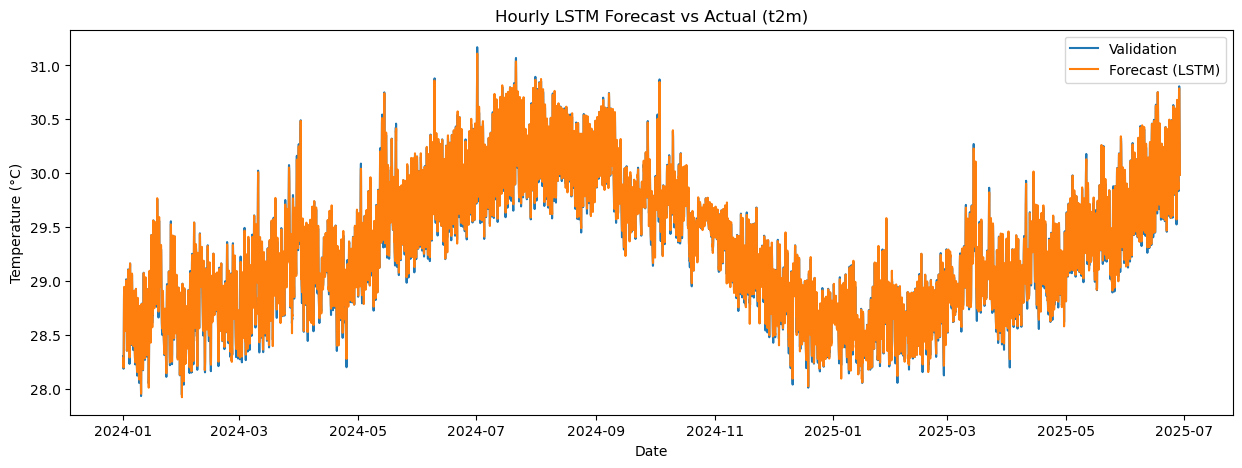


MAE: 0.027064081647727046
RMSE: 0.04090294415774981


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

df = pd.read_csv("../../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'])
df = df.set_index('valid_time')

# Scaling
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['t2m']])

# Create supervised sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(df_scaled, seq_length)

# Train/Validation split
train_size = df.loc[:'2023-12-31'].shape[0] - seq_length
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:], y[train_size:]

# LSTM Model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Prediction
y_pred_scaled = model.predict(X_val)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_val_true = scaler.inverse_transform(y_val)

# Plot
val_index = df.index[train_size + seq_length:]
plt.figure(figsize=(15,5))
plt.plot(val_index, y_val_true, label='Validation')
plt.plot(val_index, y_pred, label='Forecast (LSTM)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly LSTM Forecast vs Actual (t2m)')
plt.legend()
plt.show()

# Evaluation
mae = mean_absolute_error(y_val_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_true, y_pred))
print()
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
